### This notebook generates figure 2 of the Shahbazi et al. 2026 paper

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu
import cortico_cereb_connectivity.summarize as summarize

#### Load models

In [29]:
# Load the best models
best_models_L2reg, _ = summarize.get_model(''.join(gl.dscode), "Icosahedron1002", "L2reg", "A2_global")
best_models_NNLS, _ = summarize.get_model(''.join(gl.dscode), "Icosahedron1002", "NNLS", "A0_global")

w_nnls = best_models_NNLS.coef_
w_ridge = best_models_L2reg.coef_

def cdf_curve(w):
    w = np.ravel(w)
    x = np.sort(w)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_r, y_r = cdf_curve(w_ridge)
x_n, y_n = cdf_curve(w_nnls)

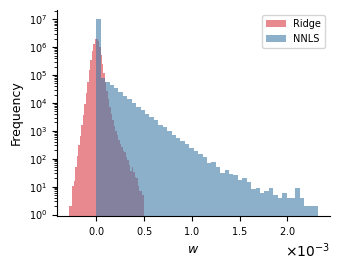

In [47]:
plt.figure(figsize=(3.5, 2.8))
ax = plt.gca()

colors = plu.get_color_palette()
ax.hist(w_ridge.flatten(), bins=50, color=colors["L2reg"], alpha=0.6, label='Ridge')
ax.hist(w_nnls.flatten(), bins=50, color=colors["NNLS"], alpha=0.6, label='NNLS')
ax.set_xlabel(r'$w$', fontsize=9)
ax.set_ylabel('Frequency', fontsize=9)
ax.set_yscale('log')
ax.legend(fontsize=7)
ax.tick_params(labelsize=7)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
sns.despine()
plt.tight_layout()

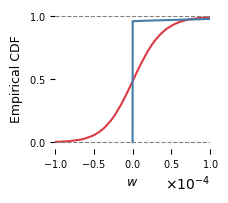

In [ ]:
plt.figure(figsize=(2, 1.8))

ax = plu.plot_emp_CDF(x_r, y_r, x_n, y_n)
ax.set_xlim(-1e-4, 1e-4)
ax.set_ylabel('Empirical CDF', fontsize=9)
ax.set_xlabel(r'$w$', fontsize=9)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)

plt.yticks([0, 0.5, 1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.despine(left=True, bottom=True)
ax.tick_params(labelsize=7)

if save_plots:
    plt.savefig(gl.fig_dir + "/fig02_a.pdf", bbox_inches="tight", dpi=300)

#### Non-zero weights and Sparsity

In [25]:
threshold = 1e-8
percent_ridge = np.sum(np.abs(w_ridge) > threshold) / w_ridge.size * 100
percent_nnls = np.sum(np.abs(w_nnls) > threshold) / w_nnls.size * 100

nonzero_count_ridge = np.sum(np.abs(w_ridge) > threshold, axis=1)
nonzero_count_nnls = np.sum(np.abs(w_nnls) > threshold, axis=1)

print(f'Percent of non-zero weights (Ridge): {percent_ridge:.2f}%')
print(f'Percent of non-zero weights (NNLS): {percent_nnls:.2f}%')

print(f'\nNumber of non-zero weights per voxel (Ridge): {nonzero_count_ridge.mean():.1f} ± {nonzero_count_ridge.std():.2f}')
print(f'Number of non-zero weights per voxel (NNLS): {nonzero_count_nnls.mean():.1f} ± {nonzero_count_nnls.std():.2f}')

Percent of non-zero weights (Ridge): 99.97%
Percent of non-zero weights (NNLS): 3.96%

Number of non-zero weights per voxel (Ridge): 1875.5 ± 0.71
Number of non-zero weights per voxel (NNLS): 74.4 ± 16.92
